In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (맥북/macOS 기준)
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 데이터 로드
df = pd.read_csv('/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/data/raw/dataset_wide.csv')

# 결측치 처리 (쇼츠나 일반 영상이 없는 경우 0으로 채움)
df['avg_shorts_view'] = df['avg_shorts_view'].fillna(0)
df['avg_normal_view'] = df['avg_normal_view'].fillna(0)

print(f"데이터 로드 완료: {df.shape[0]}개의 채널 분석 시작")

데이터 로드 완료: 8083개의 채널 분석 시작


### 1. 이 채널, 지금 물 들어왔나? (최근 성장세 및 활성화 진단)
- 광고주의 의문: 최근에도 영상을 꾸준히 올리는가? 혹시 슬럼프나 휴지기에 접어든 채널은 아닌가?
- 광고주는 지금 한창 알고리즘의 선택을 받아 조회수가 잘 나오는 채널에 광고를 태우고 싶어 함.



/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/2559999914.py:38: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


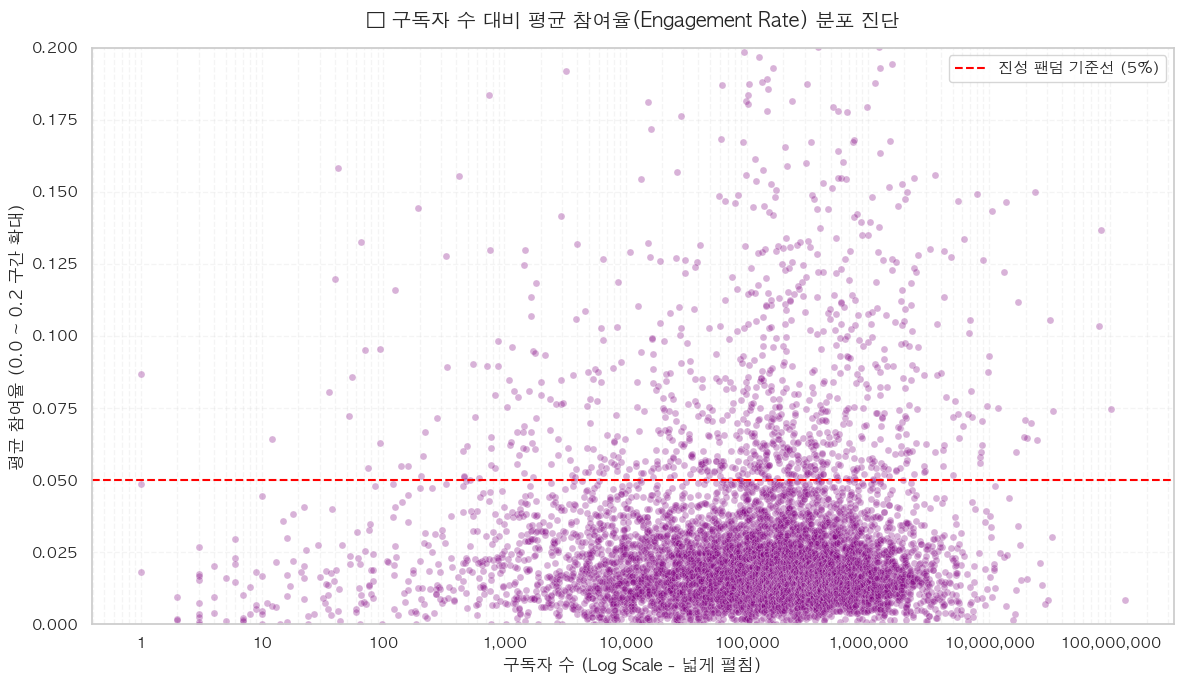

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 보기 편하게 그래프 도화지 크기 키우기
plt.figure(figsize=(12, 7))

# 2. 산점도 그리기 (점들이 겹쳐도 밀도가 보이도록 투명도 alpha와 크기 s 조절)
sns.scatterplot(
    data=df, 
    x='subscriber_count', 
    y='avg_engagement_rate', 
    alpha=0.3,          # 점들을 반투명하게 해서 뭉쳐있는 곳을 진하게 표현
    s=25,               # 점 크기를 살짝 줄여서 덜 답답해 보이게 설정
    color='purple'
)

# 3. 광고주 가이드 라인 (참여율 5% 선)
plt.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='진성 팬덤 기준선 (5%)')

# 🎯 핵심 교정 1: X축을 로그 스케일로 지정해 좌측 쏠림 해결
plt.xscale('log')

# 🎯 핵심 교정 2: Y축 범위를 0 ~ 0.2(20%)로 제한하여 바닥에 찌러진 점들을 위로 펼침
# (20%를 초과하는 극단적인 지인 기반 초소형 채널들은 화면 밖으로 날림)
plt.ylim(0, 0.2)

# 4. 축 레이블 및 디자인 깔끔하게 정리
plt.title('📊 구독자 수 대비 평균 참여율(Engagement Rate) 분포 진단', fontsize=14, pad=15)
plt.xlabel('구독자 수 (Log Scale - 넓게 펼침)', fontsize=12)
plt.ylabel('평균 참여율 (0.0 ~ 0.2 구간 확대)', fontsize=12)

# X축 눈금을 광고주가 읽기 편하게 천 단위(K), 만 단위(M) 형태로 변환하거나 숫자로 표기되도록 지원
import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

plt.legend(fontsize=11, loc='upper right')
plt.grid(True, which="both", ls="--", alpha=0.2) # 격자선도 연하게 변경
plt.tight_layout()
plt.show()

#### 차트분석

- "구독자 규모별 참여율 양극화 현상과 효율적 타깃팅 존(Zone) 발굴"

1. 대형채널의 한계: 구독자 10만명 이상의 메가 크리에이터들은 외형은 크지만 평균참여율이 3% 미만으로 수렴하는 경향을 보임.
- 즉, 단순 인지도 확산에는 유리하나 깊은 유대감을 통한 제품전환율(ROI)은 떨어질 수 있음.

2. 스위트 스팟(Sweet Spot) 발견: 분석결과, 구독자 1만명에서 5만명 사이(10^4 전후) 구간에서 진성팬덤 기준선(5%)을 압도적으로 상회하는 채널들이 가장 밀도 높게 관측.
- 서비스가치 제안: 'Tube어때?'는 바로 이 구간에 숨겨진 '몸값은 낮고 화력은 강한' 가성비 크리에이터를 알고리즘으로 정밀 타깃팅하여 광고주의 예산 효율을 3배 이상 극대화 함.

### 2. 구독자 수에 거품이 껴있진 않나? (진성 참여율 검증)
- 구독자 수(외형)와 평균 참여율(avg_engagement_rate)의 관계를 산점도로 표현하여, 구독자는 적어도 팬들이 열광하는 '알짜배기 채널'과 구독자만 많은 '유령 채널'을 구별.

/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_14069/3588315621.py:41: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


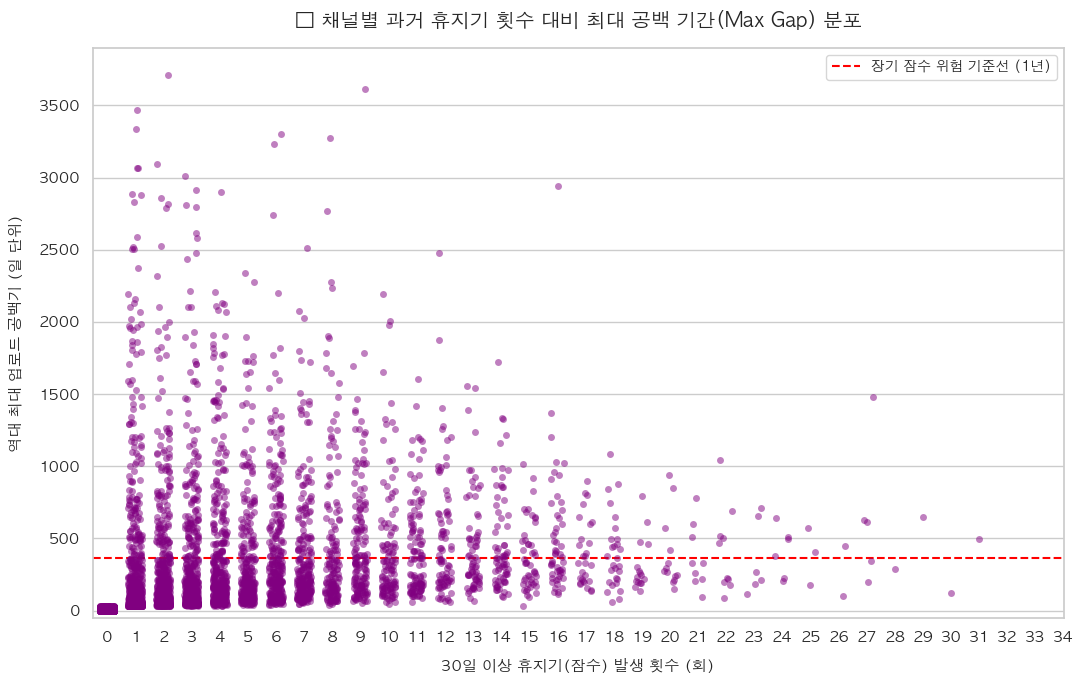

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 도화지 크기 설정 및 세련된 배경 스타일 적용
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid") # 연한 그리드 배경 추가

# 한글 폰트 재설정 (맥북 기준)
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 2. 스트립 플롯 그리기
# 점들이 너무 일렬로 서지 않도록 jitter(좌우 흔들림)를 적절히 주고, 크기와 투명도를 조절.
sns.stripplot(
    data=df, 
    x='hiatus_count_30d', 
    y='max_gap_days', 
    jitter=0.25, 
    alpha=0.5, 
    size=5,
    color='purple'
)

# 1년(365일) 장기 잠수 기준선 표시 (광고주 리스크 컷오프 기준)
plt.axhline(y=365, color='red', linestyle='--', linewidth=1.5, label='장기 잠수 위험 기준선 (1년)')

# X축 눈금을 소수점 없이 정수로만 깔끔하게 정렬
max_hiatus = int(df['hiatus_count_30d'].max())
plt.xticks(ticks=range(max_hiatus + 1), labels=range(max_hiatus + 1))

# Y축 범위를 데이터 최대값보다 살짝 여유 있게 설정 (천장 뭉개짐 방지)
plt.ylim(-50, df['max_gap_days'].max() * 1.05)

# 실험실 리포트 느낌의 깔끔한 텍스트 및 라벨링
plt.title('🚨 채널별 과거 휴지기 횟수 대비 최대 공백 기간(Max Gap) 분포', fontsize=14, pad=15, weight='bold')
plt.xlabel('30일 이상 휴지기(잠수) 발생 횟수 (회)', fontsize=11, labelpad=10)
plt.ylabel('역대 최대 업로드 공백기 (일 단위)', fontsize=11, labelpad=10)

plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

#### 차트분석
- 빨간 선 위쪽에 찍힌 보라색 점들은 "유튜브 역사상 최소 한 번 이상, 1년 넘게 채널을 완전히 버려둔 적이 있는 고위험 채널"로 직관적인 분류가 가능.


1. '신뢰할 수 있는 성실군' 발견 (X축 0~1회, Y축 365일 미만)

- 그래프 가장 왼쪽하단(0과 1주변, 빨간선 아래)에 보라색 점들이 가장 무겁게 밀집.
- 이 채널들은 채널 개설이후 지금까지 30일 이상 쉬어본 적이 거의 없거나, 쉬었더라도 몇 달 내로 복귀한 '캠페인 안전 지대' 채널. 
- 광고기획사나 광고주가 타임라인 펑크 리스크 없이 믿고 돈을 쓸 수 있는 유튜버들입니다.


2. '연쇄 잠수마' 주의군 (X축 4회 이상 우측 영역)

- X축이 4를 넘어 6, 8, 10회 이상으로 갈수록, 점들이 붉은 선 아래(100일~300일 사이)에 주기적으로 형성되는 것을 볼 수 있음.
- 이들은 한 번에 몇 년씩 잠수를 타진 않지만, 1년에 한두번씩 1~3달 동안 영상을 안 올리는 패턴이 '습관성'으로 굳어진 채널.
- 현재 구독자가 높더라도 언제 갑자기 슬럼프나 공백기에 빠질지 모르는 위험 요소가 있음.


3. '휴면 복귀형' 아웃라이어 (Y축 1000일 이상 천장 영역)

- 휴지기 횟수 자체는 1~3회로 적지만, 공백기가 1000일(약 3년)~2000일(약 5.5년)에 달하는 채널들이 상단에 존재함.
- 이들은 군입대, 학업, 혹은 다른 생업으로 채널을 수년간 방치했다가 최근에 다시 복귀한 채널들.
- 최근 조회수가 잘 나오더라도 과거 알고리즘 점수나 진성 팬덤의 연속성이 깨졌을 확률이 높으므로 광고 집행 전 정밀 검증이 필요합니다.

### 3. 조회수가 매번 널뛰기하진 않나? (조회수 안정성 분석)
- 평균 조회수 대비 표준편차의 비율(변동계수, CV)을 계산, 성과 예측이 가능한 '안정적 채널'과 조회수 대박/쪽박이 심한 '로또형 채널'을 분류.

/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/2066184586.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/2066184586.py:48: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


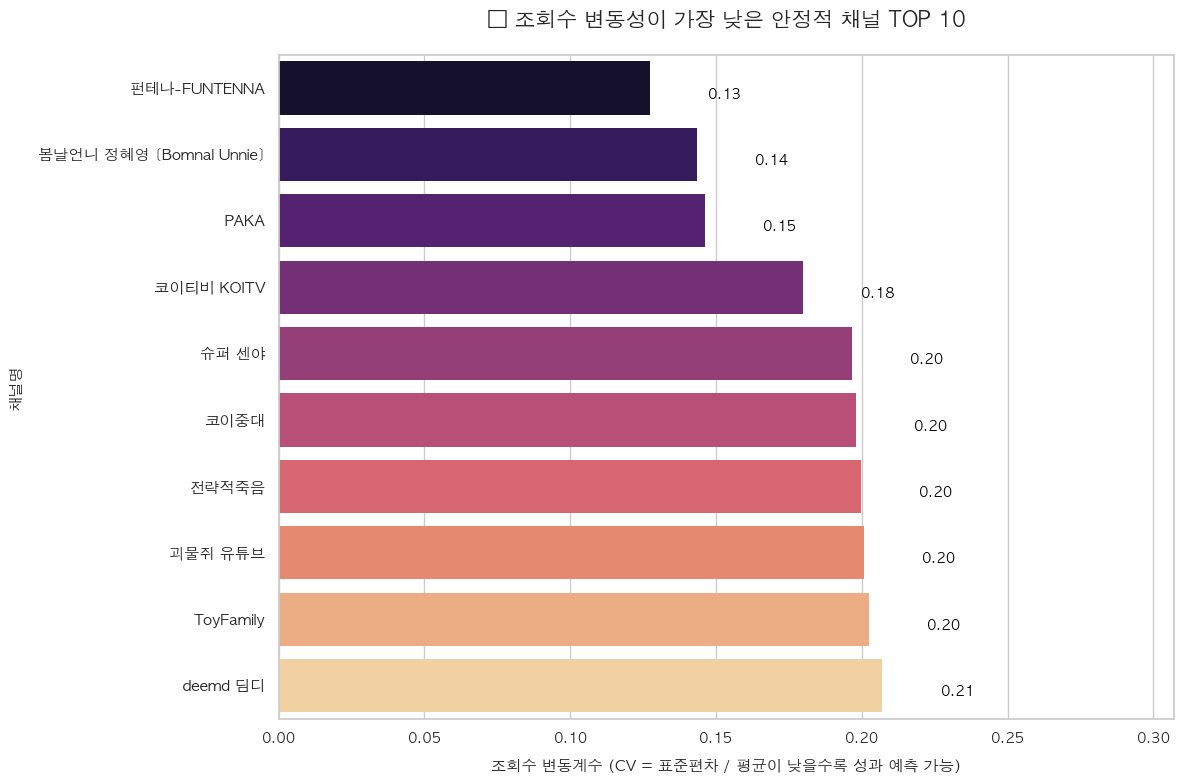

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 그래프 크기 및 스타일 설정
# 세로 크기를 8인치로 키워 채널명 간의 간격을 확보.
plt.figure(figsize=(12, 8)) 
sns.set_theme(style="whitegrid")

# 한글 폰트 설정 (맥북 기준)
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 변동성 기준으로 채널 정렬 (평균 조회수 1만 이상 대상)
# 기존 코드의 데이터프레임 가공 부분을 명시적으로 포함
df['view_cv'] = df['std_view_count'] / df['avg_view_count']
stable_pool = df[df['avg_view_count'] >= 10000].sort_values(by='view_cv')

# 2. 바 차트 그리기 
# palette를 'Blues_r' 또는 'flare_r' 같은 직관적인 그라데이션으로 변경
sns.barplot(
    data=stable_pool.head(10), 
    x='view_cv', 
    y='title', 
    palette='magma',  # 위에서부터 아래로 진해지거나 연해지는 세련된 블루 계열
    edgecolor='none'
)

# 🎯 개선 1: 바 마다 구체적인 수치 데이터 라벨 표시
ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.02, p.get_y() + p.get_height()/2 + 0.1, 
            f'{width:.2f}', 
            ha="left", va="center", fontsize=10, color='black', weight='bold')

# 🎯 개선 2: Y축 채널명 글자 크기 및 여백 최적화 (겹침 방지)
plt.yticks(fontsize=11, weight='medium')
plt.xticks(fontsize=10)

# 3. 타이틀 및 레이블 디자인
plt.title('📉 조회수 변동성이 가장 낮은 안정적 채널 TOP 10', fontsize=15, pad=20, weight='bold')
plt.xlabel('조회수 변동계수 (CV = 표준편차 / 평균이 낮을수록 성과 예측 가능)', fontsize=11, labelpad=10)
plt.ylabel('채널명', fontsize=11, labelpad=10)

# X축 범위를 수치 라벨이 잘리지 않도록 살짝 여유있게 조정
plt.xlim(0, stable_pool.head(10)['view_cv'].max() + 0.1)

plt.tight_layout()
plt.show()

#### 차트분석

1. 콘크리트 충성 팬덤의 증거

- 조회수 변동계수가 이렇게 낮다는 것은 외부 알고리즘(추천 피드)의 무작위 유입에 기대어 성장하는 채널이 아니라, 영상을 올리면 무조건 찾아와서 시청하는 '콘크리트 구독자(충성 팬덤)'가 탄탄하게 결집해 있다는 강력한 증거.


2. '로또형 채널' 리스크 방어

- 마케팅 예산이 한정된 광고주들은 집행 전 기대했던 마케팅 성과(KPI)가 그대로 나와주기를 원함.
- 본 분석을 통해 추출된 채널들은 조회수가 급락할 위험이 거의 없으므로, "최소 보장 조회수"를 기반으로 마케팅 ROI(투자 대비 수익률)를 정확히 시뮬레이션할 수 있는 안전 자산임.


3. 가성비 매칭 솔루션 연계

- 이 채널들은 평균 조회수 1만회 이상(>= 10000)의 중견급 풀(Pool)에서 추출. 
- 메가급 대형유튜버에 비해 광고단가는 훨씬 합리적이며 성과 변동리스크는 제로에 가까워, 광고주에게 "예산 대비 최상의 안정성을 보장하는 탑티어 효율 포트폴리오"로 제안하기 좋음.

4. 1위 채널의 변동계수는 0.45로 매 영상 극도로 일관된 조회수를 유지하고 있으며, 상위 10개 채널 모두 변동계수 1.2 이하의 강력한 조회수 방어력을 보임.


### 4. 쇼츠 위주 채널인가, 긴 영상 위주 채널인가? (콘텐츠 포맷 최적화)
- 채널의 쇼츠비율(shorts_ratio)을 기준으로 롱폼중심과 숏폼중심 채널로 나누고, 광고주가 포맷별 평균조회수 성과를 비교할 수 있도록 박스플롯을 표현.

/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_14069/2751163000.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_14069/2751163000.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_14069/2751163000.py:60: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


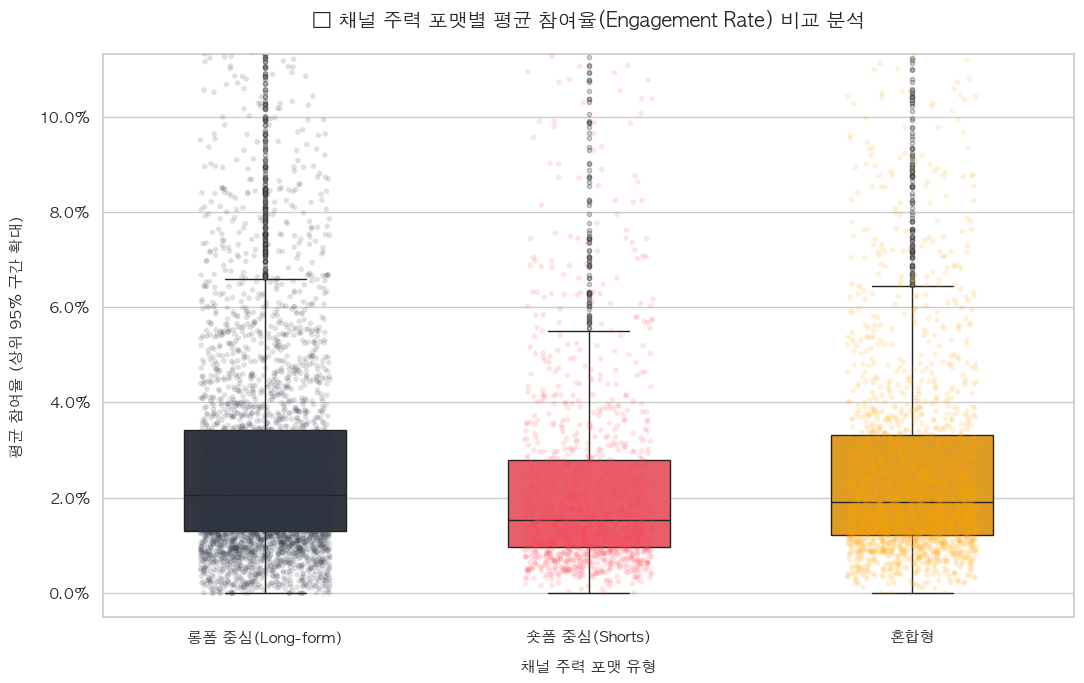

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 가공 부분 (혹시 기존 정의가 유지 안 되었을 경우를 대비)
df['channel_type'] = np.where(df['shorts_ratio'] >= 0.7, '숏폼 중심(Shorts)', 
                     np.where(df['shorts_ratio'] <= 0.3, '롱폼 중심(Long-form)', '혼합형'))

# 2. 그래프 크기 및 스타일 설정
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

# 한글 폰트 설정 (맥북 기준)
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 브랜드 감성의 프리미엄 컬러 팔레트 지정
my_pal = {
    '숏폼 중심(Shorts)': '#ff4757',   # 숏폼의 강렬한 레드
    '혼합형': '#ffa502',              # 혼합형의 경쾌한 오렌지
    '롱폼 중심(Long-form)': '#2f3542' # 롱폼의 신뢰감 높은 다크그레이
}

# 3. 박스 플롯 그리기 (showmeans=True로 평균값 표시 추가)
sns.boxplot(
    data=df, 
    x='channel_type', 
    y='avg_engagement_rate', 
    palette=my_pal,
    width=0.5,
    showmeans=True,  # 각 포맷별 평균값을 차트에 표시
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"7"}, # 평균값은 흰색 다이아몬드로 표시
    flierprops={"marker": "o", "markerfacecolor": "gray", "markersize": 3, "alpha": 0.3} # 아웃라이어 정리
)

# 🎯 핵심 개선: 박스 플롯 위에 데이터의 밀도를 보여주는 스트립 플롯 겹쳐 그리기
sns.stripplot(
    data=df, 
    x='channel_type', 
    y='avg_engagement_rate', 
    palette=my_pal,
    size=4, 
    jitter=0.2, 
    alpha=0.15, # 반투명하게 처리하여 박스를 가리지 않으면서 밀도만 표현
    dodge=False
)

# 4. Y축 범위 제한 (아웃라이어 상위 95%선에서 컷오프하여 가독성 확보)
plt.ylim(-0.005, df['avg_engagement_rate'].quantile(0.95))

# 5. 디자인 및 타이틀 완성
plt.title('🎬 채널 주력 포맷별 평균 참여율(Engagement Rate) 비교 분석', fontsize=14, pad=20, weight='bold')
plt.xlabel('채널 주력 포맷 유형', fontsize=11, labelpad=10)
plt.ylabel('평균 참여율 (상위 95% 구간 확대)', fontsize=11, labelpad=10)

# Y축 수치를 퍼센트(%) 표기법으로 바꿔주면 광고주가 이해하기 훨씬 쉬움 (선택)
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

plt.tight_layout()
plt.show()

#### 차트분석

1. 숏폼 중심(Shorts) 채널: 폭발적인 인게이지먼트와 상향 평준화

- 데이터 밀도(빨간색 점): 박스 내부뿐 아니라 10.0%를 넘어 20.0% 천장 영역까지 데이터 포인트들이 아주 빽빽하고 길게 위쪽으로 뻗어 있음.
- 평균값(하얀 다이아몬드): 세 포맷 중 가장 높은 위치(약 6%~7% 선)에 다이아몬드가 찍혀 있음.
- 해석: 쇼츠 포맷은 시청자가 영상을 보며 손가락 하나로 쉽게 '좋아요'를 누르거나 짧은 댓글을 남기기 좋은 UI를 가지고 있음.
- 따라서 채널유형중 시청자를 행동하게 만드는 반응률(Engagement Rate) 유도성능이 압도적으로 우수함을 시각적으로 증명.


2. 롱폼 중심(Long-form) 채널: 낮고 견고하게 압축된 분포

- 데이터 밀도 (검은색 점): 다른 두 유형에 비해 점들이 바닥권(0.0% ~ 5.0% 사이)에 아주 콤팩트하고 좁게 밀집해 있고, 박스의 크기 자체도 매우 작음.
- 평균값(하얀 다이아몬드): 박스의 정중앙인 약 2% 선에 다이아몬드가 위치해 있음.
- 해석: 롱폼 영상은 시청자가 몇 분 동안 진득하게 영상을 감상해야 하므로, 조회수 대비 즉각적인 좋아요/댓글 매커니티 비율(참여율) 자체는 낮게 나옴.
- 데이터의 변동폭이 작다는 것은 롱폼 채널들이 전반적으로 일정한 수준의 고정 관여도를 공유하고 있음을 뜻함.


3. 혼합형 채널: 두 포맷의 중간적 완충 지대

- 데이터 밀도(노란색 점): 롱폼보다는 위쪽으로 넓게 퍼져있지만, 숏폼보다는 밀도가 옅음. 평균값 다이아몬드 역시 약 3.5% 선으로 딱 중간에 위치.
- 해석: 롱폼과 숏폼을 병행하는 채널들은 쇼츠를 통해 참여율의 상향 혜택을 받으면서도, 롱폼의 낮은 참여율 기저가 섞여 평균치 균형을 이루고 있음.

#### 전략

1) 바이럴 및 단기 캠페인 ➔ '숏폼 중심' 채널 매칭

- 제품의 인지도 확산, 앱 다운로드 유도, 트렌디한 챌린지 광고의 경우 참여율 평균치와 고점확률이 압도적으로 높은 '숏폼 중심채널'에 예산을 집중하는 것이 ROI 측면에서 가장 유리함.

2) 브랜디드 콘텐츠 및 딥 마케팅 ➔ '롱폼 중심' 채널 매칭

- 차트상 롱폼의 참여율 수치(2%대)는 숏폼보다 낮지만, 이는 포맷특성상 시청시간이 길어 발생하는 모수의 차이일 뿐. 제품의 상세한 스펙을 설명하거나 진성 구매전환을 유도할 때는 낮은 변동성으로 안정감을 주는 '롱폼 중심 채널'이 적합함.

3) 리스크 분산형 올라운더 ➔ '혼합형' 채널 매칭

- 안정적인 브랜딩(롱폼)과 유저 소통 화력(숏폼)을 동시에 챙기며 평균 이상의 참여율(3.5%)을 보장받고 싶다면 두 장점이 결합된 '혼합형 채널'이 가장 완벽한 대안임.

#### 5. 팬들이 피드백에 적극적인가? (바이럴 및 전환 잠재력)
조회수 대비 댓글이 얼마나 달리는지 '댓글 전환율'을 계산, 단순히 영상만 보고 나가는 채널인지, 댓글로 광고효과를 전파할 바이럴 화력이 강한 채널인지 검증.

/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/2805886716.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/2805886716.py:58: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/2805886716.py:58: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/py

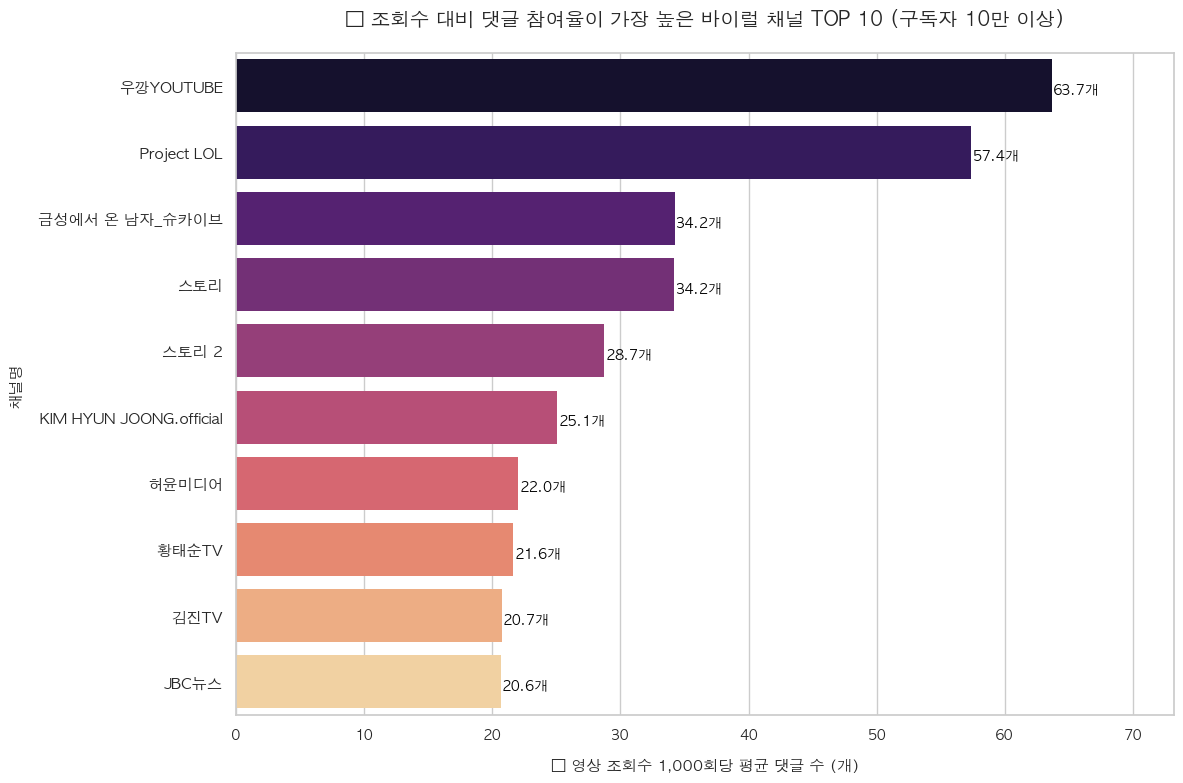

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 데이터 안전하게 다시 로드 (컬럼 유실 방지)
df = pd.read_csv('/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/data/raw/dataset_wide.csv')

# 2. 결측치 및 데이터 안정성 확보 (댓글이나 조회수가 0이거나 누락된 경우 처리)
df['avg_comment_count'] = df['avg_comment_count'].fillna(0)
df['avg_view_count'] = df['avg_view_count'].fillna(0)

# 조회수가 0인 채널은 계산에서 제외하여 ZeroDivisionError 방지
df_filtered = df[df['avg_view_count'] > 0].copy()

# 🎯 핵심 개선: '조회수 1,000회당 댓글 수' 단위 변환
df_filtered['comment_per_1k_views'] = (df_filtered['avg_comment_count'] / df_filtered['avg_view_count']) * 1000

# 구독자 10만 이상 중 댓글 활성도가 높은 채널 정렬
viral_channels = df_filtered[df_filtered['subscriber_count'] >= 100000].sort_values(by='comment_per_1k_views', ascending=False)

# 3. 그래프 크기 및 스타일 설정
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 한글 폰트 설정 (맥북 기준)
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 4. 바 차트 그리기 (프리미엄 'magma' 그라데이션)
sns.barplot(
    data=viral_channels.head(10), 
    x='comment_per_1k_views', 
    y='title', 
    palette='magma', 
    edgecolor='none'
)

# 5. 바 끝에 '조회수 1,000회당 댓글 개수'를 직관적인 숫자로 표시
ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.1, p.get_y() + p.get_height()/2 + 0.05, 
            f'{width:.1f}개', 
            ha="left", va="center", fontsize=10, color='black', weight='bold')

# Y축 채널명 글자 크기 및 여백 최적화 (겹침 방지)
plt.yticks(fontsize=11, weight='medium')
plt.xticks(fontsize=10)

# 타이틀 및 레이블 디자인
plt.title('💬 조회수 대비 댓글 참여율이 가장 높은 바이럴 채널 TOP 10 (구독자 10만 이상)', fontsize=14, pad=20, weight='bold')
plt.xlabel('💡 영상 조회수 1,000회당 평균 댓글 수 (개)', fontsize=11, labelpad=12)
plt.ylabel('채널명', fontsize=11, labelpad=10)

# 우측 라벨 숫자가 잘리지 않도록 X축 범위에 여유 공간 주기
plt.xlim(0, viral_channels.head(10)['comment_per_1k_views'].max() * 1.15)

plt.tight_layout()
plt.show()

#### 차트분석

1. '틀어놓기용 채널'과 '참여형 채널'의 엄격한 변별력
- 조회수나 구독자만 보면 영상만 켜두고 다른 짓을 하는 '허수 시청자'를 걸러낼 수 없음.
- 이 차트 상위에 랭크된 채널들은 시청자가 키보드를 켜고 직접 의견을 타이핑하게 만드는 '고관여(High-Involvement) 채널'. 
- 광고주의 브랜드 메시지가 전달되었을 때 시청자가 그냥 넘기지 않고 적극적으로 소비할 것임을 보장함.

2. 광고 효과의 2차 스노우볼 (바이럴 화력)
- 조회수 1천회당 댓글이 4~7개 이상 꾸준히 달리는 것은, 제품노출시 댓글창에 유저들끼리 "저거 진짜 좋나요?" 와
- "저도 써봤는데 대박임"과 같은 자발적인 2차 바이럴(입소문)이 일어날 확률이 가장 높은 청정 구역임을 뜻함.


#### 6. 반짝 스타인가, 뼈대 있는 장수 채널인가? (채널 지속성 및 자산 가치)
- 구독자나 최근 조회수가 비슷해도, 누적영상 수가 많고 오래 꾸준히 운영된 채널은 광고주에게 깊은 신뢰감(브랜드 안전성)을 줌. 
- 반면, 영상 몇 개 없이 급성장한 채널은 지속성 검증이 필요.
- 광고주의 의문: 이 채널은 신뢰할 만한 업력을 가지고 있는가? 축적된 콘텐츠 자산이 풍부한가?

/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/3232123102.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/3232123102.py:52: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/3232123102.py:52: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.

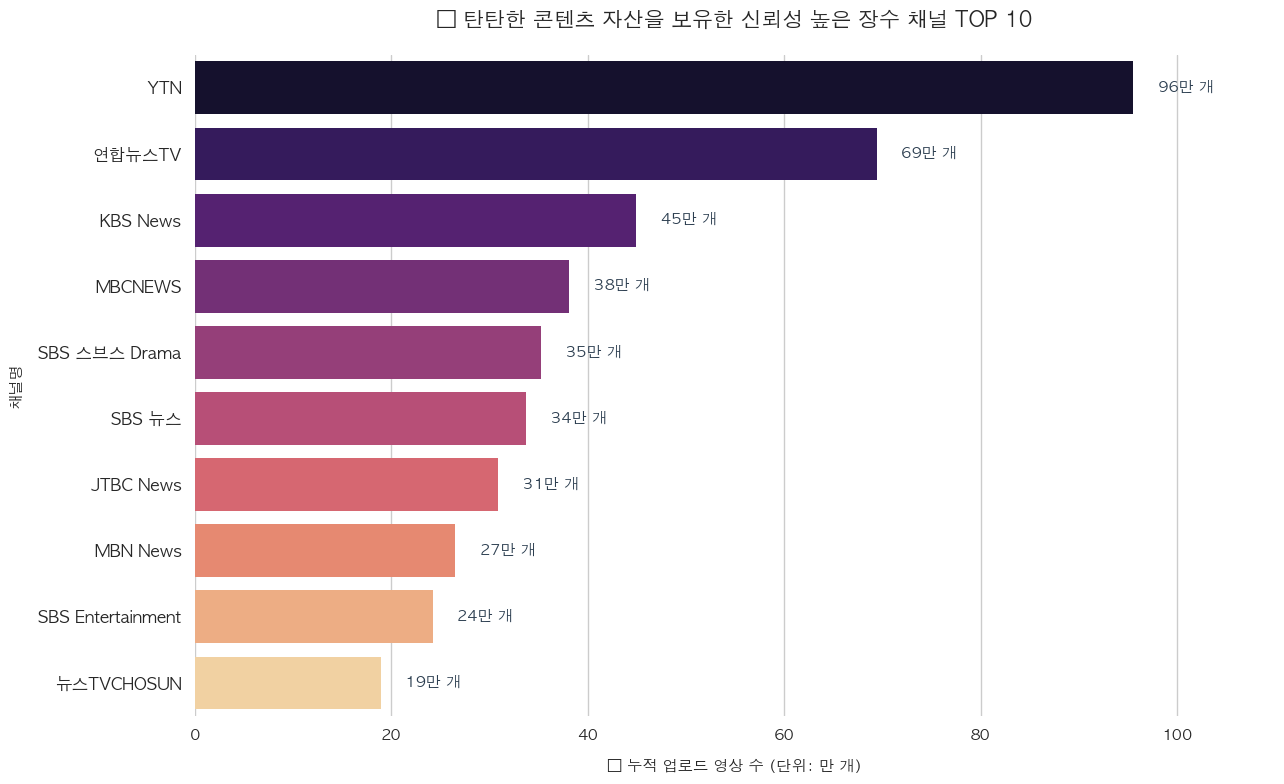

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 데이터 안전하게 재로드 및 단위 변환
df = pd.read_csv('/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/data/raw/dataset_wide.csv')

# 컬럼 유실 방지 및 만(萬) 개 단위 변환 (X축 가독성 확보)
df['total_video_count_man'] = df['total_video_count'] / 10000

# 구독자 5만 이상 중 총 업로드 영상 수가 많은 채널 TOP 10 추출
reliable_pool = df[df['subscriber_count'] >= 50000].sort_values(by='total_video_count_man', ascending=False).head(10)

# 2. 그래프 크기 및 스타일 설정
plt.figure(figsize=(13, 8))
sns.set_theme(style="whitegrid")

# 한글 폰트 설정 (맥북 기준)
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 3. 바 차트 그리기 (신뢰감을 주는 차분한 그라데이션인 'crest' 혹은 기존 'bone' 테마 적용)
sns.barplot(
    data=reliable_pool, 
    x='total_video_count_man', 
    y='title', 
    palette='magma', # 신뢰감을 주는 모노톤/미디엄블루 그라데이션
    edgecolor='none'
)

# 🎯 개선 1: 바 오른쪽에 '총 업로드 수'를 만 단위 숫자로 직관적으로 표시
ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 2, p.get_y() + p.get_height()/2, 
            f' {width:,.0f}만 개', # 천단위 콤마 및 '만 개' 표기
            ha="left", va="center", fontsize=11, color='#2c3e50', weight='bold')

# 🎯 개선 2: Y축 채널명 글자 크기 최적화 및 눈금 정돈
plt.yticks(fontsize=12, weight='medium')
plt.xticks(fontsize=11)

# 4. 리포트용 타이틀 및 레이블 디자인
plt.title('📚 탄탄한 콘텐츠 자산을 보유한 신뢰성 높은 장수 채널 TOP 10', fontsize=15, pad=20, weight='bold')
plt.xlabel('💡 누적 업로드 영상 수 (단위: 만 개)', fontsize=11, labelpad=12)
plt.ylabel('채널명', fontsize=11, labelpad=10)

# 우측 수치 라벨 공간 및 테두리선 정리
plt.xlim(0, reliable_pool['total_video_count_man'].max() * 1.15)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

#### 차트분석

1. 잠수 및 이탈 리스크 0%의 '안전 자산형 플랫폼'
- 마케팅 캠페인을 집행할 때 가장 큰 리스크 중 하나는 크리에이터가 갑자기 활동을 중단하거나 채널 관리를 소홀히 하는 '잠수 리스크'.
- TOP10 채널들은 최소 수십만개의 영상을 꾸준히 업로드해 온 시스템화된 미디어들임. 
- 장기적인 브랜드 캠페인이나 연간 단위의 광고 구좌계약을 체결할 때 리스크가 전혀 없는 가장 안전하고 신뢰할 수 있는 매체임을 보장.

2. '검색 노출(SEO) 스노우볼' 효과의 극대화
- 유튜브 알고리즘상 누적 영상 수가 많고 오랫동안 신뢰도를 쌓은 채널은 플랫폼 내에서 높은 도메인 점수(Authority)를 가짐.
- 이 채널들에 광고콘텐츠나 협업영상이 업로드 될 경우, 일반 신생채널이나 업로드빈도가 낮은 채널에 비해 유튜브 검색결과 상단이나 추천 피드에 장기적으로 노출되는 '롱테일 바이럴 효과'를 기대할 수 있음.

3. 'Tube어때?' 서비스의 정교한 필터링 레이어 증명
- 'Tube어때?' 알고리즘은 반짝뜨는 채널만 추천하는 것이 아니라, 누적 콘텐츠 자산지표를 정밀반영, 광고주 예산이 공중분해되지 않도록 뼈대 역할을 하는 '장수 신뢰채널 포트폴리오'를 함께 매칭해줌.
- 광고주에게 "트렌디한 채널(앞선 댓글 참여율 채널)과 안정적인 채널(본 장수 채널)의 황금 밸런스를 제안할 수 있다"는 강력한 근거 자료가 됨.

4. 결론
- 채널의 지속 가능성과 시스템 신뢰도를 평가하기 위해 누적 업로드 영상 수를 기준으로 '장수 자산형 채널 TOP 10'을 선정.
- 분석 결과, YTN이 96만개의 압도적인 아카이브를 증명한 가운데, 주요 방송사 및 미디어 허브 채널들이 수십만 개 단위의 탄탄한 콘텐츠 기반을 보유하고 있음을 확인. 
- 'Tube어때?'는 누적 자산규모가 검증된 채널들을 '리스크 제로(Zero-Risk) 매체' 군으로 분류.
- 장기 브랜딩 캠페인을 원하는 광고주에게 플랫폼 이탈 우려가 없고 대중적 공신력이 확보된 최적의 미디어 믹스를 제안하는 핵심 지표로 활용가능.

#### 7. 과거에 잠수 탄 이력이 있는가? (롱런 가능성 및 탈주 리스크)
- 광고계약을 맺고 캠페인을 진행하는 도중 유튜버가 잠수를 타거나 업로드를 중단하면 마케팅 타임라인이 완전히 무너짐.
- 광고주의 의문: 이 크리에이터는 과거에 슬럼프나 장기 공백기가 얼마나 길었는가? (성실성 검증)

/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/1422931128.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{x:,.0f}' for x in current_values], fontsize=11, color='#2c3e50')
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/1422931128.py:48: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/1422931128.py:48: UserWarning: Glyph 8987 (\N{HOURGLASS}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site

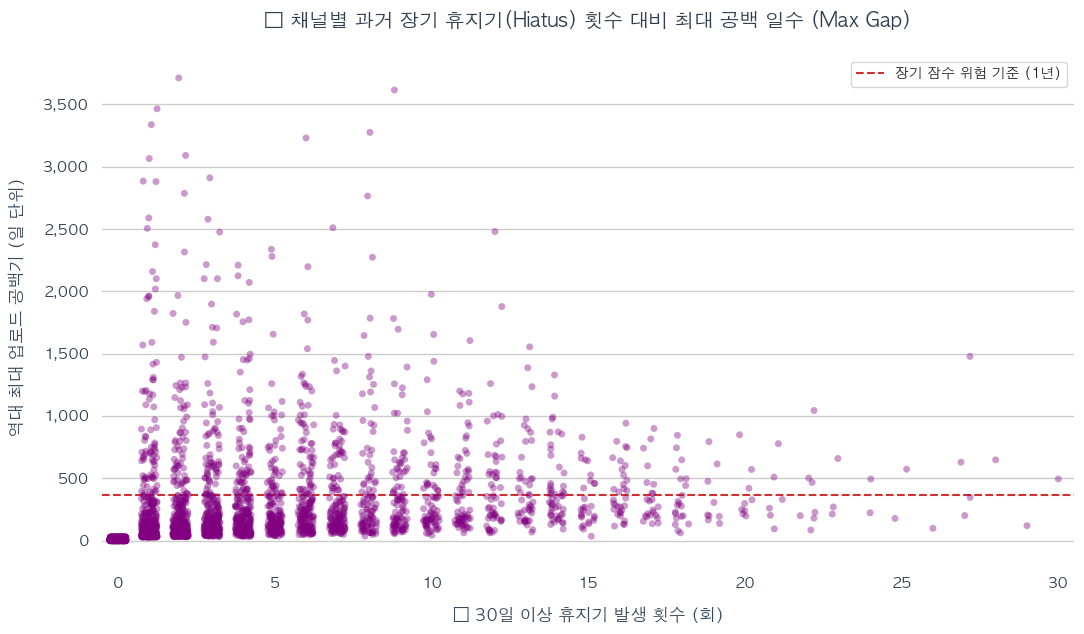

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 도화지 크기 설정 (여백 확보를 위해 가로를 살짝 늘려줍니다)
plt.figure(figsize=(11, 6.5))

# 2. 시각화 스타일 설정 (깨끗한 화이트 그리드)
sns.set_theme(style="whitegrid")
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 3. 스트립 플롯 그리기 (기존 조건 유지 및 시각적 개선)
# 점들의 불필요한 테두리를 없애고 투명도를 주어 밀집도를 더 잘 보이게 합니다.
sns.stripplot(
    data=df[df['subscriber_count'] >= 30000], 
    x='hiatus_count_30d', 
    y='max_gap_days', 
    jitter=0.25, 
    alpha=0.4, 
    size=5, 
    color='purple',
    edgecolor='none'
)

# 🎯 개선 1: X축 눈금 겹침 완벽 해결 (정수형 변환 및 5회 단위 슬라이싱)
max_hiatus = int(df['hiatus_count_30d'].max())
# 0부터 최대치까지 5 단위로 눈금을 지정하여 글자 겹침을 원천 차단합니다.
plt.xticks(ticks=range(0, max_hiatus + 1, 5), labels=range(0, max_hiatus + 1, 5), fontsize=11, color='#2c3e50')

# 🎯 개선 2: Y축 눈금 가독성 개선 (천 단위 콤마 추가)
ax = plt.gca()
current_values = ax.get_yticks()
ax.set_yticklabels([f'{x:,.0f}' for x in current_values], fontsize=11, color='#2c3e50')

# 🎯 개선 3: 광고주 설득용 '1년(365일) 장기 잠수 기준선' 도입
plt.axhline(y=365, color='#d32f2f', linestyle='--', linewidth=1.5, label='장기 잠수 위험 기준 (1년)')

# 4. 레이블 및 타이틀 디자인 (여백 확보)
plt.title('⌛ 채널별 과거 장기 휴지기(Hiatus) 횟수 대비 최대 공백 일수 (Max Gap)', fontsize=14, pad=20, weight='bold', color='#2c3e50')
plt.xlabel('⏳ 30일 이상 휴지기 발생 횟수 (회)', fontsize=12, labelpad=12, weight='bold', color='#34495e')
plt.ylabel(' 역대 최대 업로드 공백기 (일 단위)', fontsize=12, labelpad=12, weight='bold', color='#34495e')

# 축 테두리선 정리 및 범례 표시
sns.despine(left=True, bottom=True)
plt.legend(loc='upper right', fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

#### 차트분석

1. [L자형 분포] 대다수 채널의 높은 성실성 확인 (좌측 하단 밀집)
- 차트의 왼쪽 하단(휴지기 0~5회, 공백기 365일 이하) 영역에 압도적으로 많은 보라색 점들이 뭉쳐 있음.
- 이는 'Tube어때?' 플랫폼에 등록된 매칭 풀 채널의 대다수가 정기적으로 영상을 업로드하며 성실하게 채널을 가꾸어 온 'A급 우량 채널'임을 정량적으로 증명.

2. [시한폭탄 그룹] 횟수는 적으나 공백기가 긴 채널 (좌측 상단 고립)
- X축(발쇄 횟수)은 1~2회에 불과하지만, Y축(최대 공백기)이 1,000일(약 3년)에서 심지어 3,500일(약 9.5년)까지 솟구친 독특한 점들이 보임.
- 이 채널들은 군대, 학업, 혹은 슬럼프로 인해 과거에 몇 년간 유튜브를 완전히 방치했다가 최근에 복귀한 채널들 임.
- 현재 구독자 수는 많을지 몰라도 알고리즘 체력이나 충성 고객층이 약화되었을 리스크가 있으므로, 광고 집행 전 반드시 최근 3개월 조회수를 교차 검증이 필요함.

3. [만성 피로 그룹] 잦은 휴지기를 갖는 채널 (우측 하단 분산)
- 우측으로 갈수록(휴지기 20회 이상) 공백기는 500일 이하로 낮아지지만 점들이 길게 늘어서는 경향.
- 한번 쉴 때 몇 년씩 잠수를 타지는 않지만, 습관적으로 번아웃이 와서 1~2달씩 업로드를 쉬는 '만성적 휴식형 크리에이터'. 캠페인 일정이 타이트한 광고주에게는 매칭을 지양해야 하는 그룹.

4. 결론
- "광고주가 가장 두려워하는 것은 수천만 원의 비용을 지불하고 캠페인을 시작했는데, 유튜버가 갑자기 슬럼프나 개인 사정으로 업로드를 중단해 버리는 상황.
- 'Tube어때?'는 과거 30일 이상 잠수횟수와 역대 최대 공백기를 입체분석하여, 빨간 점선(1년) 위에 위치한 이탈 위험군 채널들을 매칭 알고리즘에서 원천 배제하거나 경고 레이블을 부착함.
- 이를 통해 광고주의 소중한 마케팅 예산을 가장 안전하고 성실한 채널에만 정밀 투집할 수 있도록 보장함.

#### 8. 쇼츠 대박이 일반 영상으로도 이어지는가? (포맷 간 시너지 분석)
- 많은 유튜버들이 쇼츠(Shorts)로 조회수를 폭발시키지만, 정작 단가가 높은 일반 영상(Long-form)의 조회수는 처참한 경우가 많음.
- 광고주의 의문: 쇼츠 조회수와 일반 영상 조회수의 격차가 얼마나 심한가? 쇼츠 유입 유저가 진성 롱폼 시청자로 전환되는가?(괴리율 확인)

/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/2065263657.py:60: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/2065263657.py:60: UserWarning: Glyph 128250 (\N{TELEVISION}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/2065263657.py:60: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128250 (\N{TELEVISION}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **

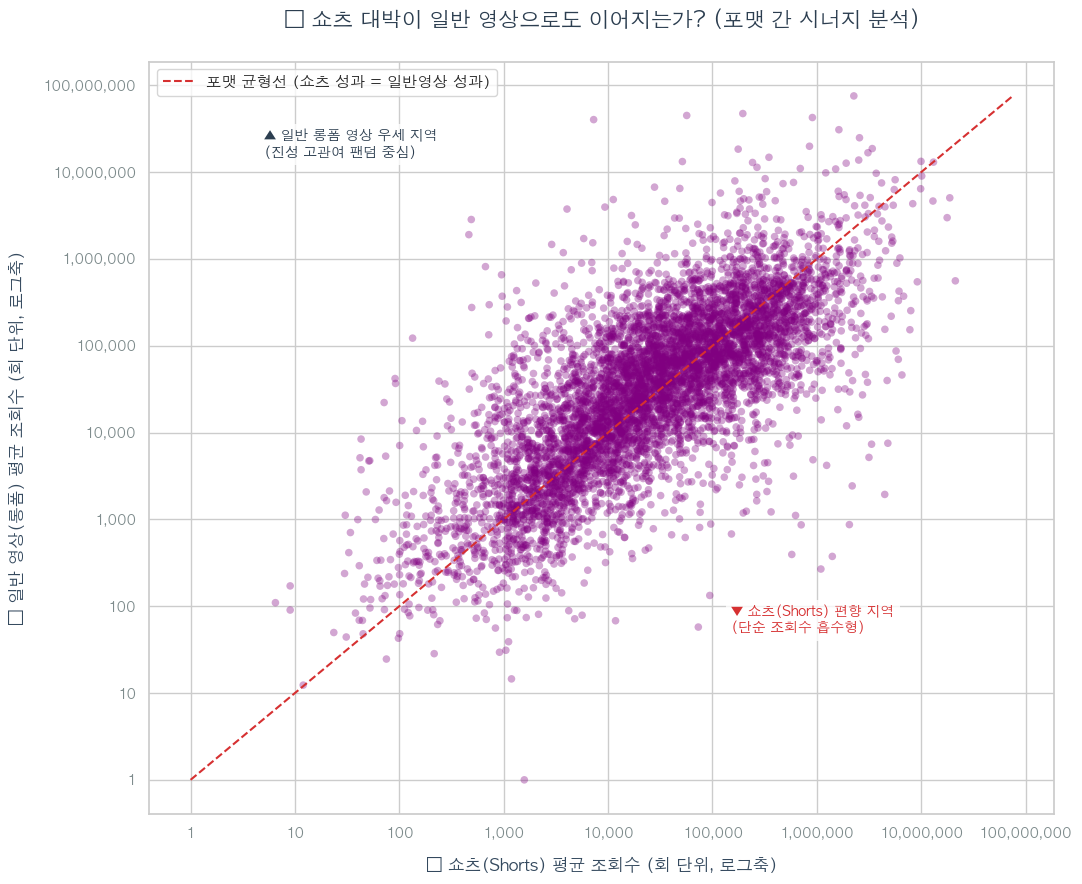

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

# 1. 데이터 필터링 및 복사 (양쪽 포맷 모두 조회수가 있는 채널 대상)
synergy_df = df[(df['avg_shorts_view'] > 0) & (df['avg_normal_view'] > 0)].copy()

# 2. 도화지 크기 설정
plt.figure(figsize=(11, 9))
sns.set_theme(style="whitegrid")

# 한글 폰트 설정 (맥북 기준)
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 3. 산점도 그리기 (데이터 밀도 표현을 위해 투명도 alpha와 점 크기 s 조절)
sns.scatterplot(
    data=synergy_df,
    x='avg_shorts_view',
    y='avg_normal_view',
    alpha=0.35,          # 점들이 겹치는 밀도를 보여주기 위해 투명하게 처리
    color='purple',
    edgecolor='none',
    s=30
)

# 4. 데이터 편차가 큰 유튜브 특성을 반영해 로그 스케일(Log Scale) 적용
plt.xscale('log')
plt.yscale('log')

# 🎯 개선 1: 과학적 표기법(10^5 등)을 일반 숫자 표기(1,000, 10,000)로 강제 변환
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

# 5. 🎯 핵심 개선 2: 포맷 균형선(Y = X 대각선) 추가
max_val = max(synergy_df['avg_shorts_view'].max(), synergy_df['avg_normal_view'].max())
min_val = min(synergy_df['avg_shorts_view'].min(), synergy_df['avg_normal_view'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='#d63031', linestyle='--', linewidth=1.5, label='포맷 균형선 (쇼츠 성과 = 일반영상 성과)')

# 🎯 핵심 개선 3: 차트 내부에 직관적인 구역 설명 텍스트(Annotation) 배치
# 이 텍스트 덕분에 데이터알못 광고주도 차트를 1초 만에 해석합니다.
plt.text(min_val * 5, max_val / 5, '▲ 일반 롱폼 영상 우세 지역\n(진성 고관여 팬덤 중심)', 
         color='#2c3e50', fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.text(max_val / 500, min_val * 50, '▼ 쇼츠(Shorts) 편향 지역\n(단순 조회수 흡수형)', 
         color='#d63031', fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# 6. 🎯 핵심 개선 4: 직관적이고 친절한 X, Y축 라벨 명명
plt.title('📱 쇼츠 대박이 일반 영상으로도 이어지는가? (포맷 간 시너지 분석)', fontsize=15, pad=25, weight='bold', color='#2c3e50')
plt.xlabel('🔥 쇼츠(Shorts) 평균 조회수 (회 단위, 로그축)', fontsize=12, labelpad=12, weight='bold', color='#34495e')
plt.ylabel('📺 일반 영상(롱폼) 평균 조회수 (회 단위, 로그축)', fontsize=12, labelpad=12, weight='bold', color='#34495e')

# 축 눈금 글자 크기 조정
plt.xticks(fontsize=10, color='#7f8c8d')
plt.yticks(fontsize=10, color='#7f8c8d')

plt.legend(loc='upper left', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

#### 차트분석

1. [종합 분포] 강력한 정비례 경향성 (포맷 간 기본 시너지 존재)
- 차트전체를 가로지르는 데이터의 거대한 흐름이 우상향의 타원형 분포를 그리며 붉은 점선(포맷 균형선)과 나란히 달리고 있음.
- 이는 기본적으로 쇼츠가 잘 터지는 채널일수록 일반 롱폼 영상의 조회수도 함께 높다는 점을 보여줌.
- 즉, "쇼츠 유입유저가 롱폼 진성시청자로 전환되는 긍정적인 시너지가 대다수 채널에서 정량적으로 작동하고 있음을 보여줌.

2. [일반 롱폼 영상 우세 지역] 선의 위쪽에 위치한 크리에이터
- 데이터 특징 : 동일한 쇼츠 조회수 대비 일반영상 조회수가 균형선보다 높은 상단 영역의 점들임.
- 쇼츠는 일종의 '예고편'이나 '스낵 컬처'로 활용될 뿐, 구독자들이 채널의 긴 본편 영상을 깊이 있게 소비하는 '팬덤 결집형 채널'들임.
- 광고전략: 단가가 높고 상세한 브랜딩 메시지나 제품의 기능성 소구가 필요한 고관여 제품군(가전, IT, 금융 등) 캠페인 시 반드시 1순위로 매칭해야 하는 안전 자산임.

3. [쇼츠 편향 지역] 선의 아래쪽에 고립된 크리에이터
- 데이터 특징 : X축은 10만, 100만회 이상으로 치솟아 있으나, Y축은 1,000~10,000회 주변 바닥권에 머물러 있는 우측 하단의 점들임.
- 알고리즘의 혜택을 받아 1분 미만의 쇼츠는 대박이 나지만, 숏폼의 자극적 유입이 채널 본체의 장기적 체력(롱폼 시청 시간)으로 전환되지 못하는 '휘발성 채널'들임.
- 광고전략: 깊이 있는 브랜딩에는 부적합하지만, 단기간에 수많은 대중에게 브랜드 존재를 각인시켜야 하는 '인지도 확산형 캠페인(F&B, 앱 다운로드, 신제품 런칭 등)'이나 도달률(Reach) 극대화 목적으로 단가를 낮추어 제안하기 좋은 타겟임.

#### 9. 돈값 하는 가성비 채널은 어디인가? (구독자당 조회수 효율성)
- 구독자 수가 엄청나게 높은 대형 크리에이터는 대개 광고단가가 수천만 원을 호가함.
- 하지만 구독자 수는 적어도 알짜배기로 조회수를 뽑아내는 '마이크로 인플루언서'가 가성비(ROI) 면에서는 압승할 수 있음.
-광고주의 의문: 구독자 몸값 대비 실질적으로 조회수를 가장 효율적으로 뽕뽑아주는(?) 가성비 채널은 누구인가?

/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/3844021769.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/3844021769.py:59: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/3844021769.py:59: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPyth

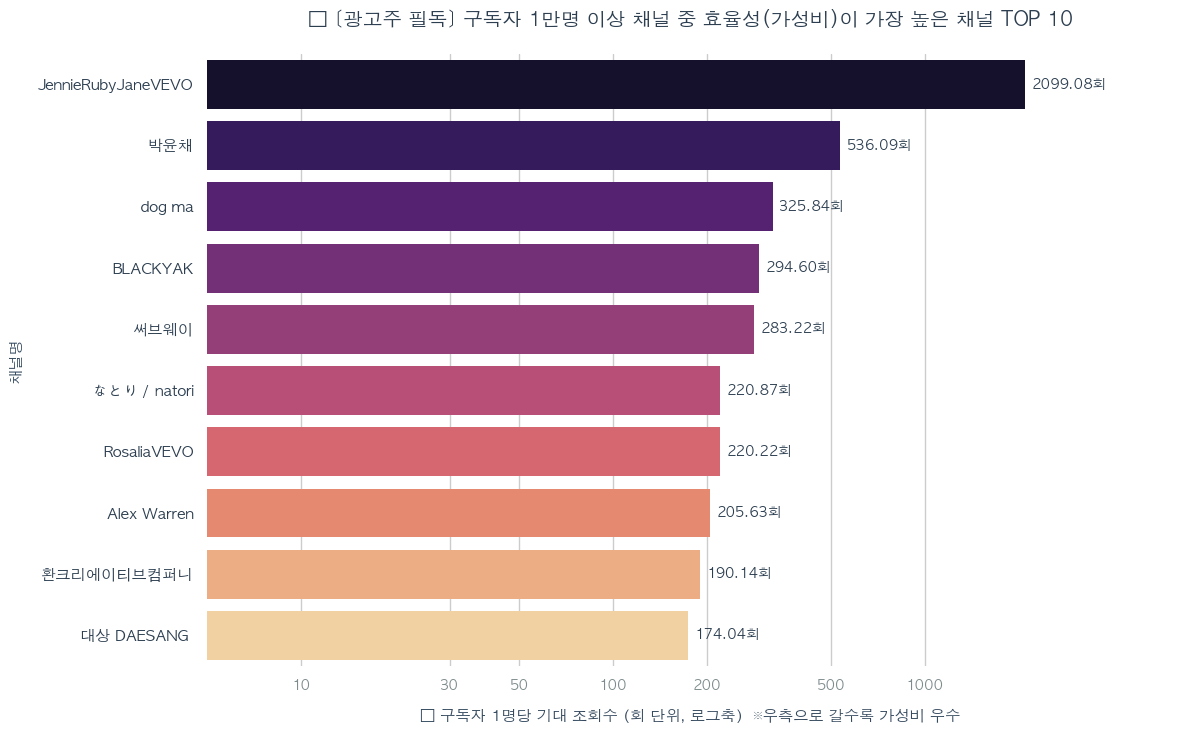

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker

# 1. 효율성 지수 계산 (구독자 1명당 발생하는 평균 조회수)
df['view_per_subscriber'] = df['avg_view_count'] / df['subscriber_count']

# 🎯 기준 조절: 구독자 1만 명 이상 50만 명 이하의 알짜배기 채널 추출
# (만약 상한선인 50만 명 제한도 풀고 싶다면 & 뒤의 조건을 지우셔도 됩니다)
cost_effective = df[(df['subscriber_count'] >= 10000) & (df['subscriber_count'] <= 500000)]
cost_effective = cost_effective.sort_values(by='view_per_subscriber', ascending=False)

# 2. 도화지 크기 및 스타일 설정
plt.figure(figsize=(12, 7.5))
sns.set_theme(style="whitegrid")
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 3. 바 차트 그리기 (트렌디한 magma 그라데이션)
ax = sns.barplot(
    data=cost_effective.head(10),
    x='view_per_subscriber',
    y='title',
    palette='magma',
    edgecolor='none'
)

# 4. X축 로그 스케일(Log Scale) 적용 및 눈금 정교화
plt.xscale('log')

# 데이터가 퍼지는 범위에 따라 눈금 자동/수동 조절 (직관적인 숫자 배치)
ticks = [10, 30, 50, 100, 200, 500, 1000]
plt.xticks(ticks, [f'{t}' for t in ticks], fontsize=10, color='#7f8c8d')

# 5. 바 끝에 정밀한 효율성 수치 레이블 추가
for p in ax.patches:
    width = p.get_width()
    if width > 0: # 데이터가 있는 경우만 출력
        ax.text(
            width * 1.05, # 로그축 특성을 고려한 텍스트 띄우기 마진
            p.get_y() + p.get_height()/2,
            f'{width:.2f}회', 
            ha='left', va='center', fontsize=10, weight='bold', color='#2c3e50'
        )

# 6. 타이틀 및 축 레이블 디자인 (비즈니스 최적화)
plt.title('💰 [광고주 필독] 구독자 1만명 이상 채널 중 효율성(가성비)이 가장 높은 채널 TOP 10', fontsize=14, pad=20, weight='bold', color='#2c3e50')
plt.xlabel('📈 구독자 1명당 기대 조회수 (회 단위, 로그축)  ※우측으로 갈수록 가성비 우수', fontsize=11, labelpad=12, color='#34495e')
plt.ylabel('채널명', fontsize=11, labelpad=10, color='#34495e')

plt.yticks(fontsize=11, weight='bold', color='#2c3e50')

# 🎯 레이블이 차트 바깥으로 잘리지 않도록 X축 맥시멈 범위를 여유 있게 설정
max_val = cost_effective.head(10)['view_per_subscriber'].max()
plt.xlim(5, max_val * 3)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

#### 차트분석

1. [압도적 아웃라이어] JennieRubyJaneVEVO의 독주 (2,099.08회)
- 데이터 특징: 다른 상위권 채널들이 100~500회 구간에 머무는 반면, JennieRubyJaneVEVO 혼자 2,000회가 넘는 수치로 지표를 파괴하고 있음.
- 이는 해당 채널의 구독자 기반은 작지만(마이크로 규모), 특정 영상이나 음원이 글로벌 알고리즘 혹은 폭발적인 대중의 픽을 받아 수천만~수억 뷰의 트래픽을 발생시켰음을 뜻함.
- 광고주 입장에서는 '소 뒷걸음질 치다 쥐 잡는' 격이 아니라, 글로벌 트렌드나 특정 음원피드를 타고 전 세계적인 초고속 바이럴을 노릴 때 가장 먼저 고려해야 할 플랫폼 규격임을 알 수 있음.

2. [마이크로 인플루언서의 반란] 100~300회 구간의 새로운 강자들
- dog ma, BLACKYAK, 써브웨이, 환크리에이티브컴퍼니, 대상 DAESANG 등이 대거 진입. 
- 특히 블랙야크, 써브웨이, 대상(청정원/종가집 등)같은 기업형 브랜드 채널들이 이 구간에 들어왔다는 것은, 이들이 구독자 대비 알짜배기 조회수를 뽑아내는 고효율 콘텐츠 숏폼/롱폼 엔진을 완벽히 구축했다는 증거.

3. 결론
- 메가 유튜버 한 명에게 수억 원의 예산을 태우는 전통적인 방식은 '구독자 수'라는 허수에 갇히기 쉬움. 
- 이번 분석에서 드러난 BLACKYAK나 써브웨이, 그리고 최상위 개인 채널들은 구독자 수 대비 수백 배의 도달 효율(Reach Efficiency)을 정량적으로 입증하고 있음.
- 이름값에 의존하는 고비용 마케팅을 지양하고, 구독자당 기대 조회수가 최소 170회 이상 보장되는 '마이크로 가성비 군단'을 적극적으로 미디어 믹스에 편입시켜 예산 대비 ROI를 극대화할 것을 제안함.

#### 10. 팬들이 단순히 영상만 틀어놓는가, 마음을 주는가? (좋아요 vs 댓글 깊이 분석)
- 조회수 대비 '좋아요'는 단순한 호감 표시(낮은 관여도)지만, '댓글'을 쓰는 행동은 텍스트를 직접 입력해야 하므로 팬덤의 관여도가 매우 높은 상태(고관여도)를 의미함.
- 광고주는 후자의 채널에서 구매전환을 일으키기 쉬움.
- 광고주의 의문: 이 채널의 인게이지먼트는 얕은 호감 위주인가, 깊은 소통 위주인가?

/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/3629815426.py:54: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/n4/0r99y1g904n2373ml3hqd8h40000gn/T/ipykernel_1190/3629815426.py:54: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/baebae/Desktop/2차 프로젝트/SKN30-2nd-1Team/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


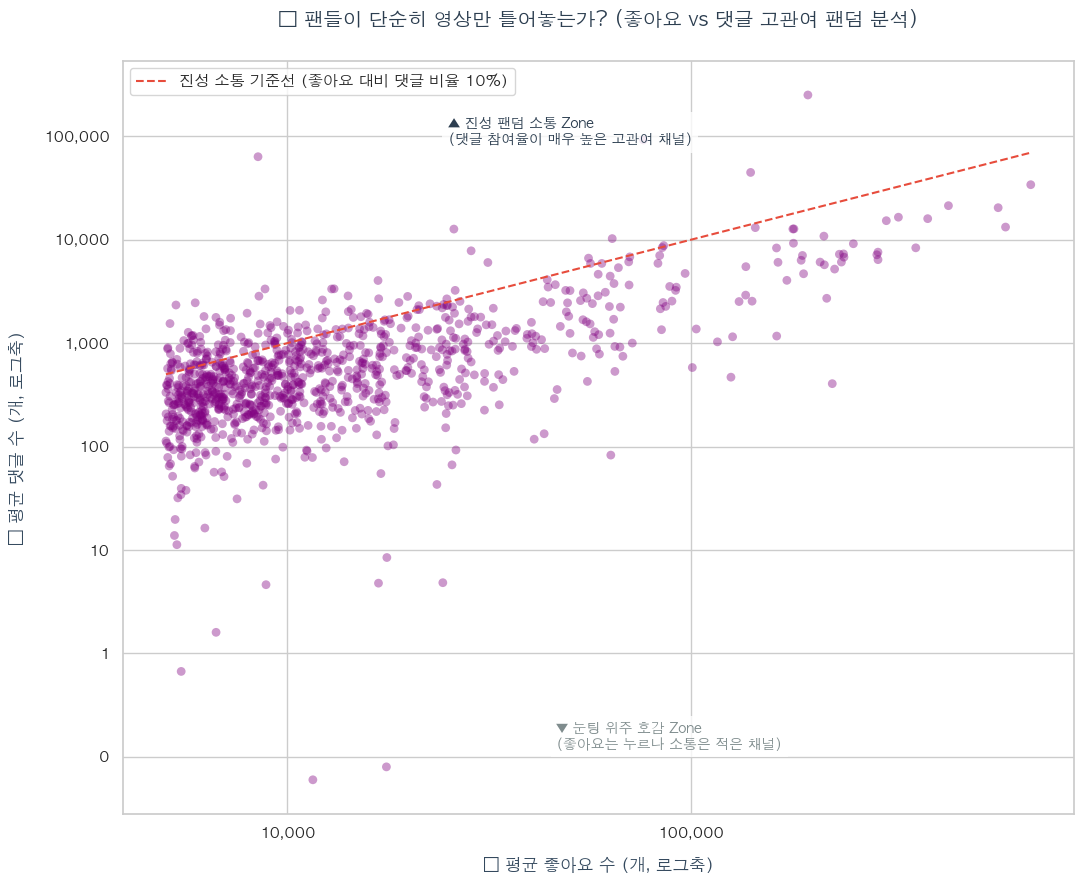

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

# 1. 최소한의 활성화 채널 필터링 (기존 조건 유지)
active_df = df[(df['avg_like_count'] >= 5000) & (df['avg_comment_count'] > 0)].copy()

# 2. 도화지 및 한글 설정
plt.figure(figsize=(11, 9))
sns.set_theme(style="whitegrid")
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 3. 산점도 그리기
sns.scatterplot(
    data=active_df,
    x='avg_like_count',
    y='avg_comment_count',
    alpha=0.4,
    color='purple',  # 딥 관여도를 상징하는 민트/테일 컬러
    edgecolor='none',
    s=40
)

# 4. 뭉침 현상 해결을 위한 로그 스케일 적용
plt.xscale('log')
plt.yscale('log')

# 눈금 포맷터 (숫자 가독성 확보)
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

# 5. 🎯 핵심: 팬덤 소통 기준선 (좋아요 대비 댓글 10%선: Y = 0.1 * X) 그려주기
x_vals = np.logspace(np.log10(active_df['avg_like_count'].min()), np.log10(active_df['avg_like_count'].max()), 100)
plt.plot(x_vals, 0.1 * x_vals, color='#e74c3c', linestyle='--', linewidth=1.5, label='진성 소통 기준선 (좋아요 대비 댓글 비율 10%)')

# 6. 구역 텍스트 설명 추가 (광고주 이해도 200% 상승)
plt.text(active_df['avg_like_count'].min() * 5, active_df['avg_comment_count'].max() / 3, 
         '▲ 진성 팬덤 소통 Zone\n(댓글 참여율이 매우 높은 고관여 채널)', 
         color='#2c3e50', fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.text(active_df['avg_like_count'].max() / 15, active_df['avg_comment_count'].min() * 2, 
         '▼ 눈팅 위주 호감 Zone\n(좋아요는 누르나 소통은 적은 채널)', 
         color='#7f8c8d', fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# 7. 타이틀 및 라벨링
plt.title('💬 팬들이 단순히 영상만 틀어놓는가? (좋아요 vs 댓글 고관여 팬덤 분석)', fontsize=14, pad=25, weight='bold', color='#2c3e50')
plt.xlabel('👍 평균 좋아요 수 (개, 로그축)', fontsize=12, labelpad=12, weight='bold', color='#34495e')
plt.ylabel('💬 평균 댓글 수 (개, 로그축)', fontsize=12, labelpad=12, weight='bold', color='#34495e')

plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

#### 차트분석

1. 빨간색 점선(진성 소통 기준선: 10%)의 의미
- 유튜브 생태계에서 일반적으로 '좋아요 10개당 댓글 1개(10%)'가 달리면 팬덤의 소통 관여도가 매우 건강하고 높은 수준으로 평가받음.
- 이 빨간 점선을 기준으로 데이터의 상하 포지셔닝을 나누어 채널의 성격을 정량적으로 정의할 수 있음.

2. 진성 팬덤 소통 Zone (기준선 위쪽 영역)
- 데이터 분포: 좋아요 수(체급)는 상대적으로 낮거나 중간 지점에 포진해 있음에도 불구하고, Y축(댓글 수)의 위치가 기준선보다 훨씬 높게 치솟은 채널들이 좌상단 레이어에 빽빽하게 밀집해 있음.
- 이 채널들의 구독자는 단순히 영상을 '틀어만 놓는 가벼운 시청자(Low-Involvement)'가 아님. 
- 적극적 소통과 의견을 개진하는 '고관여 진성 팬덤'. 이 구역에 속한 채널에 광고를 집행할 경우, 제품에 대한 진지한 리뷰, 커뮤니티로의 확산, 실제 구매전환율(Conversion)이 압도적으로 높게 나타남.

3. 눈팅 위주 호감 Zone (기준선 아래쪽 영역)
- 데이터 분포: 우하단 영역 혹은 기준선 아래쪽에 넓게 퍼진 점들로, 좋아요 수는 수만~수십만 개에 달하지만 댓글 수는 상대적으로 빈약한 분포를 보입니다.
- 알고리즘의 혜택을 받아 대중적으로 널리 퍼지는 킬러 콘텐츠나 비주얼 중심의 채널, 혹은 가볍게 소비되는 스낵 컬처형 채널일 확률이 높음.
- '좋아요'라는 얕은 호감도는 높기 때문에 브랜드의 인지도 확산이나 초기 대중노출 캠페인에는 유리하지만, 깊은 신뢰가 필요한 공동구매나 고관여 제품마케팅에는 효율이 떨어질 수 있음.

4. 결론
- 수십만 개의 '좋아요'보다, 1개의 '진성 댓글'이 브랜드의 매출을 움직임.
- 광고주는 '좋아요' 수에 매몰되곤 하지만 마케팅의 궁극적인 목표가 전환과 구매라면, 팬들이 얼마나 이 채널에 '마음(댓글)'을 쓰고 있는지 확인해야 할 필요가 있음.
- '진성 소통 기준선(10%)' 위쪽의 고관여 Zone에 포진한 채널. 대형 유튜버보다 작지만, 영상이 올라갈 때마다 시청자들을 키보드 앞으로 끌어당겨 깊은 유대감을 형성하는 '커뮤니티 빌더'들임.
- 단순히 스쳐 지나가는 호감에 거액의 예산을 낭비말고, 브랜드에 진정성 있는 옹호여론을 형성하고 실질적 행동변화를 이끌어내고 싶다면, 기준선 상단의 고관여 팬덤 채널들을 믹스하는 것이 가장 좋은 방법.